## Precipitation Partitioning
Follows Wang 2019

In [1]:
%matplotlib ipympl
import matplotlib.pyplot as plt
import numpy as np
from buildforcing.datasets import siteNLDAS
from datetime import datetime
import os

### Key Functions

In [2]:
# Saturation vapor pressure over liquid water
def esat_liq(T):
    # Magnus formula - see Huang 2018
    # T in degC, esat in Pa
    return 610.94 * np.exp((17.625 * T) / (T + 243.04))  # in Pa

In [15]:
# Saturation vapor pressure over ice
def esat_ice(T):
    # Also from Huang 2018
    # T in degC, esat in Pa
    return 611.21 * np.exp((22.587 * T) / (T + 273.86))  # in Pa

In [3]:
# Specific humidity to vapor pressure
def q_to_e(q, p):
    # q in kg/kg, p in Pa, e in Pa
    # See downloaded list of formulas from "plymouth state"
    return (q * p) / (0.622 + 0.378 * q)

In [4]:
# Psychrometric constant
def psychro_const(p):
    # p in Pa, gamma in Pa/K
    cp = 1005.7  # J/(kg·K)
    Lv = 2.5e6  # J/kg
    epsilon = 0.622  # Rd/Rv
    return (cp * p) / (epsilon * Lv)  # in Pa/K

In [5]:
# Relative humidity from q and Tair
def rh_from_q_tair(q, Tair, p):
    # q in kg/kg, Tair in degC, p in Pa, rh in fraction
    e = q_to_e(q, p)
    esat = esat_liq(Tair)
    return e / esat  # fraction

In [31]:
# Vapor pressure from wet-bulb temperature
def e_from_wetbulb(Ta, Twb, p):
    # Twb in degC, p in Pa, e in Pa
    if Twb < 0:
        esat = esat_ice(Twb)
    else:
        esat = esat_liq(Twb)
    gamma = psychro_const(p)
    return esat - gamma * (Ta - Twb)  # in Pa

### Solve for wet bulb temperature using air temperature, specific humidity, and pressure

In [36]:
def calculate_wetbulb(Ta_c, q, p_pa):
    # Ta in degC, q in kg/kg, p in Pa
    # Returns Twb in degC
    e = q_to_e(q, p_pa)  # in Pa
    gamma = psychro_const(p_pa)  # in Pa/K

    # Initial guess for Twb
    Twb = Ta_c

    # Iterative solution based in e_from_wetbulb
    for _ in range(10):
        e_calc = e_from_wetbulb(Ta_c, Twb, p_pa)
        if e_calc < 0:
            e_calc = 0  # Prevent negative vapor pressure, this limits step size making convergence slower
        error = e - e_calc
        if abs(error) < 0.01:
            break
        Twb += error / gamma  # Update Twb estimate
    
    return Twb
        

### Test Twb using some NLDAS data

In [23]:
quemazon = siteNLDAS('Quemazon',datetime(2010,4,1),datetime(2010,4,10),storage_path=os.environ['NLDAS_PATH'])
quemazon.loadNetCDF()

In [24]:
quemazon.data.head()

,LWdown,PSurf,Qair,Rainf,SWdown,Tair,Wind_E,Wind_N,elevation
Date&Time,,,,,,,,,
2010-04-01 00:00:00+00:00,204.01,71718.2,0.002184,0.0,225.983,284.45,6.78,10.20,2827.595947
2010-04-01 01:00:00+00:00,203.92,71678.7,0.002004,0.0,61.886,282.73,6.35,9.55,2827.595947
2010-04-01 02:00:00+00:00,203.82,71638.9,0.001825,0.0,0.000,281.02,5.93,8.90,2827.595947
2010-04-01 03:00:00+00:00,201.21,71598.8,0.001647,0.0,0.000,279.30,5.50,8.26,2827.595947
2010-04-01 04:00:00+00:00,201.17,71592.0,0.001670,0.0,0.000,278.55,5.23,8.99,2827.595947


In [25]:
quemazon_data = quemazon.data[['Tair','Qair','PSurf']].copy()
quemazon_data['Tair_c'] = quemazon_data['Tair'] - 273.15  # Convert to degC

In [34]:
quemazon_data['RH'] = quemazon_data.apply(lambda row: rh_from_q_tair(row['Qair'], row['Tair_c'], row['PSurf']), axis=1)
quemazon_data['Twb_c'] = quemazon_data.apply(lambda row: calculate_wetbulb(row['Tair_c'], row['Qair'], row['PSurf']), axis=1)

Text(0.5, 0, 'Date & Time')

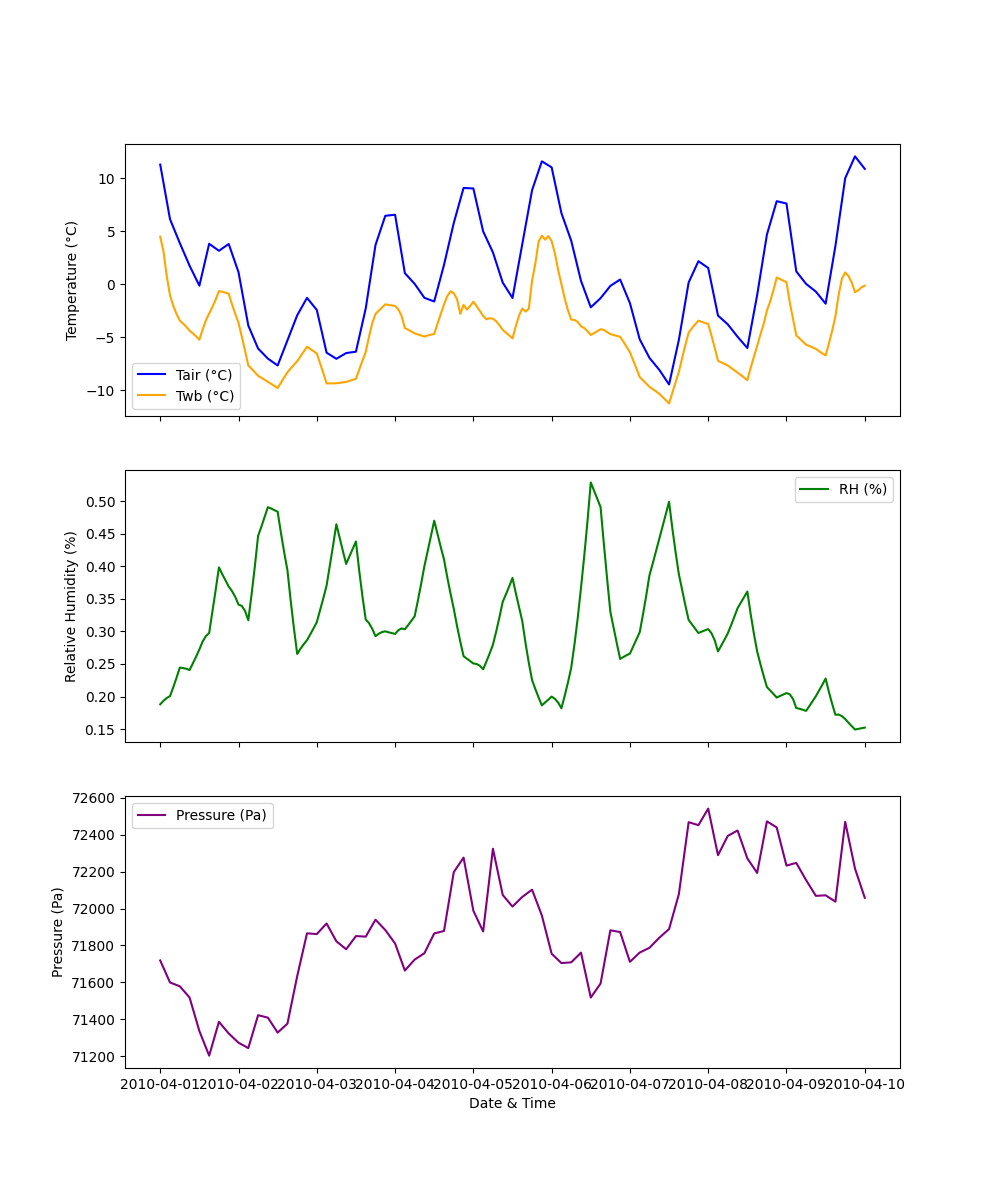

In [35]:
fig, ax = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
ax[0].plot(quemazon_data.index, quemazon_data['Tair_c'], label='Tair (°C)', color='blue')
ax[0].plot(quemazon_data.index, quemazon_data['Twb_c'], label='Twb (°C)', color='orange')
ax[0].set_ylabel('Temperature (°C)')
ax[0].legend()

ax[1].plot(quemazon_data.index, quemazon_data['RH'], label='RH (%)', color='green')
ax[1].set_ylabel('Relative Humidity (%)')
ax[1].legend()

ax[2].plot(quemazon_data.index, quemazon_data['PSurf'], label='Pressure (Pa)', color='purple')
ax[2].set_ylabel('Pressure (Pa)')
ax[2].legend()
ax[2].set_xlabel('Date & Time')

In [12]:
quemazon_data['2010-04-05 18:00':'2010-04-06 06:00'].head()

,Tair,Qair,PSurf,Tair_c,RH,Twb_c
Date&Time,,,,,,
2010-04-05 18:00:00+00:00,282.04,0.002214,72102.1,8.89,0.225230,2.334622
2010-04-05 19:00:00+00:00,282.94,0.002210,72055.6,9.79,0.211474,7.155124
2010-04-05 20:00:00+00:00,283.85,0.002206,72009.0,10.70,0.198509,10.535925
2010-04-05 21:00:00+00:00,284.76,0.002201,71962.2,11.61,0.186411,12.906608
2010-04-05 22:00:00+00:00,284.57,0.002228,71893.1,11.42,0.190819,12.636587


In [32]:
q_test = 0.0022015  # kg/kg
p_test = 71962.2  # Pa
T_test = 284.76 - 273.15  # degC
test = calculate_wetbulb(T_test, q_test, p_test)  # Example calculation
print(f"Test wet-bulb temperature: {test:.2f} °C at T={T_test:.2f} °C, q={q_test:.6f} kg/kg, p={p_test:.1f} Pa")

Test wet-bulb temperature: 14.18 °C at T=11.61 °C, q=0.002201 kg/kg, p=71962.2 Pa
